In [247]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from scipy.stats import skew


Dataset 1:- NSL KDD

In [143]:
df_train = pd.read_csv("../data/kdd_train.csv")
df_test = pd.read_csv("../data/kdd_test.csv")

In [145]:
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [147]:
print(f"Columns with object datatype:- {df_train.dtypes[df_train.dtypes == 'object'].index.tolist()}")

Columns with object datatype:- ['protocol_type', 'service', 'flag', 'labels']


In [149]:
#Converting them to int

#1)Label
df_train['attack_binary'] = df_train['labels'].apply(lambda x: 0 if x=='normal' else 1)
df_test['attack_binary'] = df_test['labels'].apply(lambda x: 0 if x=='normal' else 1)


In [151]:
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels,attack_binary
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


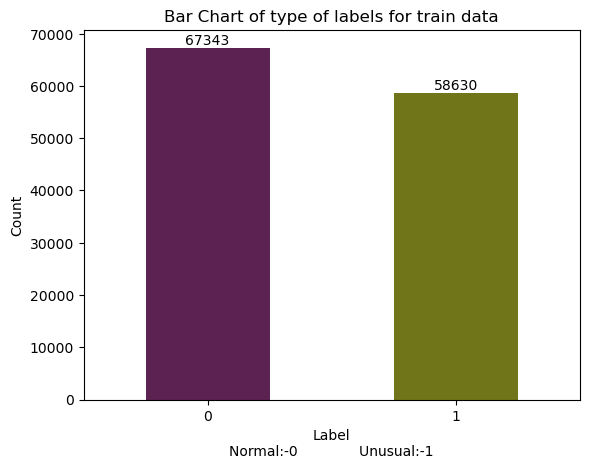

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts
counts = df_train['attack_binary'].value_counts()

bar_colors = ['#5C2252', '#707519'] 

# Plot the counts, passing the colors list
ax = counts.plot.bar(color=bar_colors)

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('Label\nNormal:-0              Unusual:-1')
plt.ylabel('Count')
plt.title('Bar Chart of type of labels for train data')
plt.xticks(rotation=0) # Keeps the category labels horizontal for better readability
plt.show()

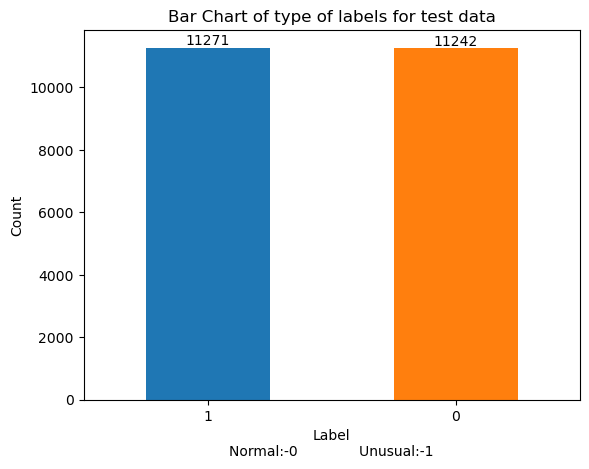

In [209]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts
counts = df_test['attack_binary'].value_counts()

bar_colors = ['#1f77b4', '#ff7f0e'] 
# Plot the counts, passing the colors list
ax = counts.plot.bar(color=bar_colors)

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('Label\nNormal:-0              Unusual:-1')
plt.ylabel('Count')
plt.title('Bar Chart of type of labels for test data')
plt.xticks(rotation=0) # Keeps the category labels horizontal for better readability
plt.show()

In [157]:
#2)Different types of protocol:

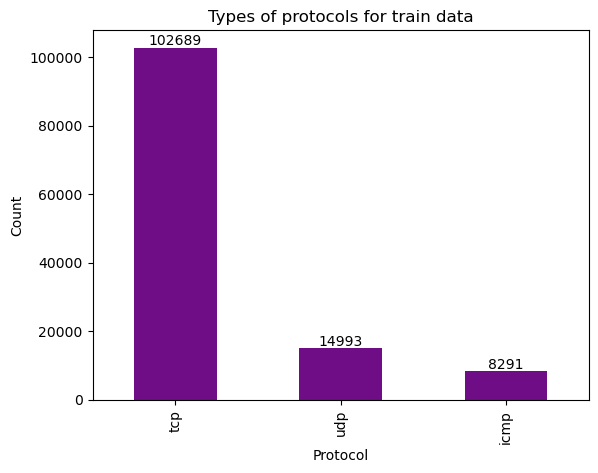

In [159]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts 
counts = df_train['protocol_type'].value_counts()

# Plot the counts directly
ax = counts.plot.bar(color = "#6F0D87")

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.title('Types of protocols for train data')
plt.show()


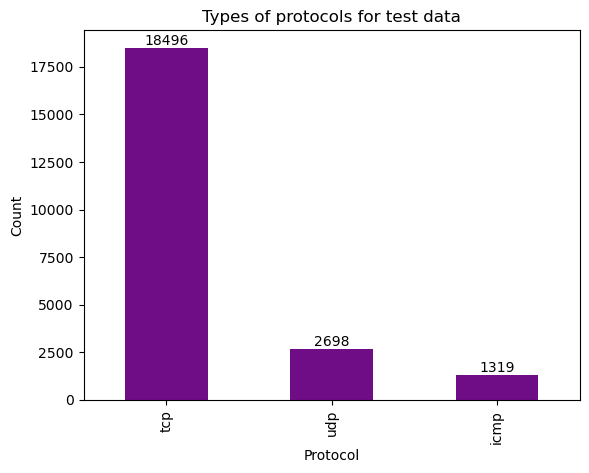

In [207]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts
counts = df_test['protocol_type'].value_counts()

# Plot the counts directly
ax = counts.plot.bar(color = "#6F0D87")

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.title('Types of protocols for test data')
plt.show()


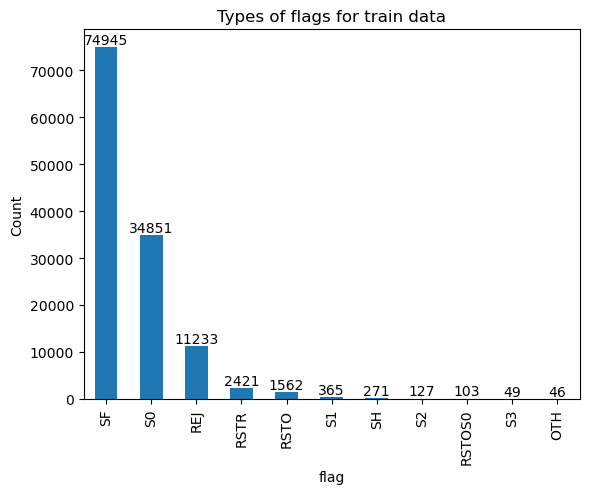

In [163]:
#3)service
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts 
counts = df_train['flag'].value_counts()

# Plot the counts directly
ax = counts.plot.bar()

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('flag')
plt.ylabel('Count')
plt.title('Types of flags for train data')
plt.show()


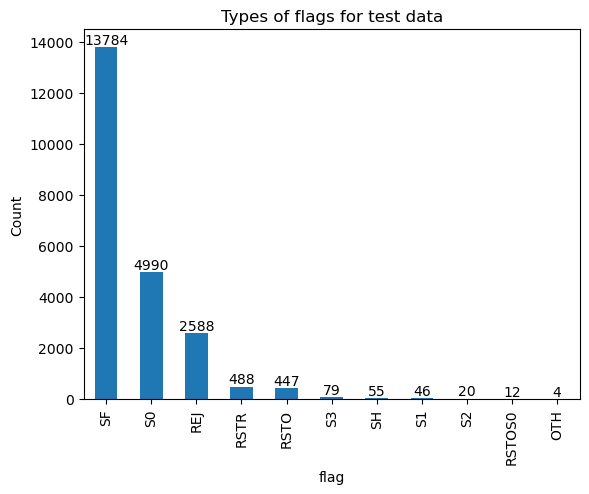

In [205]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts (this is fast even with 200,000+ rows)
counts = df_test['flag'].value_counts()

# Plot the counts directly
ax = counts.plot.bar()

# Add the labels on top of the bars
ax.bar_label(ax.containers[0])

# Add labels and a title
plt.xlabel('flag')
plt.ylabel('Count')
plt.title('Types of flags for test data')
plt.show()


In [167]:
print(f"""
Duplicate values in train data:{df_train.duplicated().sum()}
Duplicate values in test data:{df_test.duplicated().sum()}
""")


Duplicate values in train data:0
Duplicate values in test data:31



In [169]:
# AS there are duplicates in test data we need to remove those rows
df_test.drop_duplicates(inplace=True)

In [171]:
print(f"""
Duplicate values in train data:{df_train.duplicated().sum()}
Duplicate values in test data:{df_test.duplicated().sum()}
""")


Duplicate values in train data:0
Duplicate values in test data:0



In [173]:
print(f'''
Dataset Train-\n
size:-{df_train.size}\n
shape:-{df_train.shape}\n
Null values:-
{df_train.isna().sum()}\n\n
total missing value percentage:-{(df_train.isnull().sum().sum()/df_train.size ) * 100}%

preview:-\n
{df_train.head()}
''')


Dataset Train-

size:-5416839

shape:-(125973, 43)

Null values:-
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_

In [175]:
print(f'''
Dataset Test-\n
size:-{df_test.size}\n
shape:-{df_test.shape}\n
Null values:-
{df_test.isna().sum()}\n\n
total missing value percentage:-{(df_test.isnull().sum().sum()/df_test.size ) * 100}%

preview:-\n
{df_test.head()}
''')


Dataset Test-

size:-968059

shape:-(22513, 43)

Null values:-
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rat

In [177]:
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_binary']


In [179]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [183]:
train_iqr = []
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df_train, col)
    train_iqr.append({'column': col, 'lower_bound': lb, 'upper_bound': ub,
                       'pct_outliers': round(len(outliers)/len(df_train)*100, 2)})
train_iqr_df = pd.DataFrame(train_iqr)

In [185]:
train_iqr_df

,column,lower_bound,upper_bound,pct_outliers
0,duration,0.000,0.000,7.95
1,src_bytes,-414.000,690.000,10.99
2,dst_bytes,-774.000,1290.000,18.72
3,land,0.000,0.000,0.02
4,wrong_fragment,0.000,0.000,0.87
5,urgent,0.000,0.000,0.01
6,hot,0.000,0.000,2.12
7,num_failed_logins,0.000,0.000,0.10
8,logged_in,-1.500,2.500,0.00
9,num_compromised,0.000,0.000,1.02


In [187]:
test_iqr = []
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df_test, col)
    test_iqr.append({'column': col, 'lower_bound': lb, 'upper_bound': ub,
                       'pct_outliers': round(len(outliers)/len(df_train)*100, 2)})
test_iqr_df = pd.DataFrame(test_iqr)

In [189]:
test_iqr_df

,column,lower_bound,upper_bound,pct_outliers
0,duration,0.000,0.000,1.84
1,src_bytes,-412.500,687.500,2.02
2,dst_bytes,-892.500,1487.500,3.08
3,land,0.000,0.000,0.00
4,wrong_fragment,0.000,0.000,0.12
5,urgent,0.000,0.000,0.00
6,hot,0.000,0.000,0.48
7,num_failed_logins,0.000,0.000,0.15
8,logged_in,-1.500,2.500,0.00
9,num_compromised,0.000,0.000,0.23


In [191]:
comparison = train_iqr_df.merge(test_iqr_df, on='column', suffixes=('_train', '_test'))
comparison['bound_diff_upper'] = comparison['upper_bound_test'] - comparison['upper_bound_train']
print(comparison[['column', 'pct_outliers_train', 'pct_outliers_test', 'bound_diff_upper']]
      .sort_values('pct_outliers_test', ascending=False))

                         column  pct_outliers_train  pct_outliers_test  \
22              srv_serror_rate                0.00               4.41   
35     dst_host_srv_serror_rate                0.00               4.29   
21                  serror_rate                0.00               4.23   
34         dst_host_serror_rate                0.00               4.20   
27           srv_diff_host_rate               22.54               3.89   
36         dst_host_rerror_rate               18.10               3.88   
37     dst_host_srv_rerror_rate               15.37               3.70   
32  dst_host_same_src_port_rate               19.89               3.47   
33  dst_host_srv_diff_host_rate                9.27               3.16   
2                     dst_bytes               18.72               3.08   
23                  rerror_rate               12.85               3.01   
24              srv_rerror_rate               12.86               2.97   
1                     src_bytes       

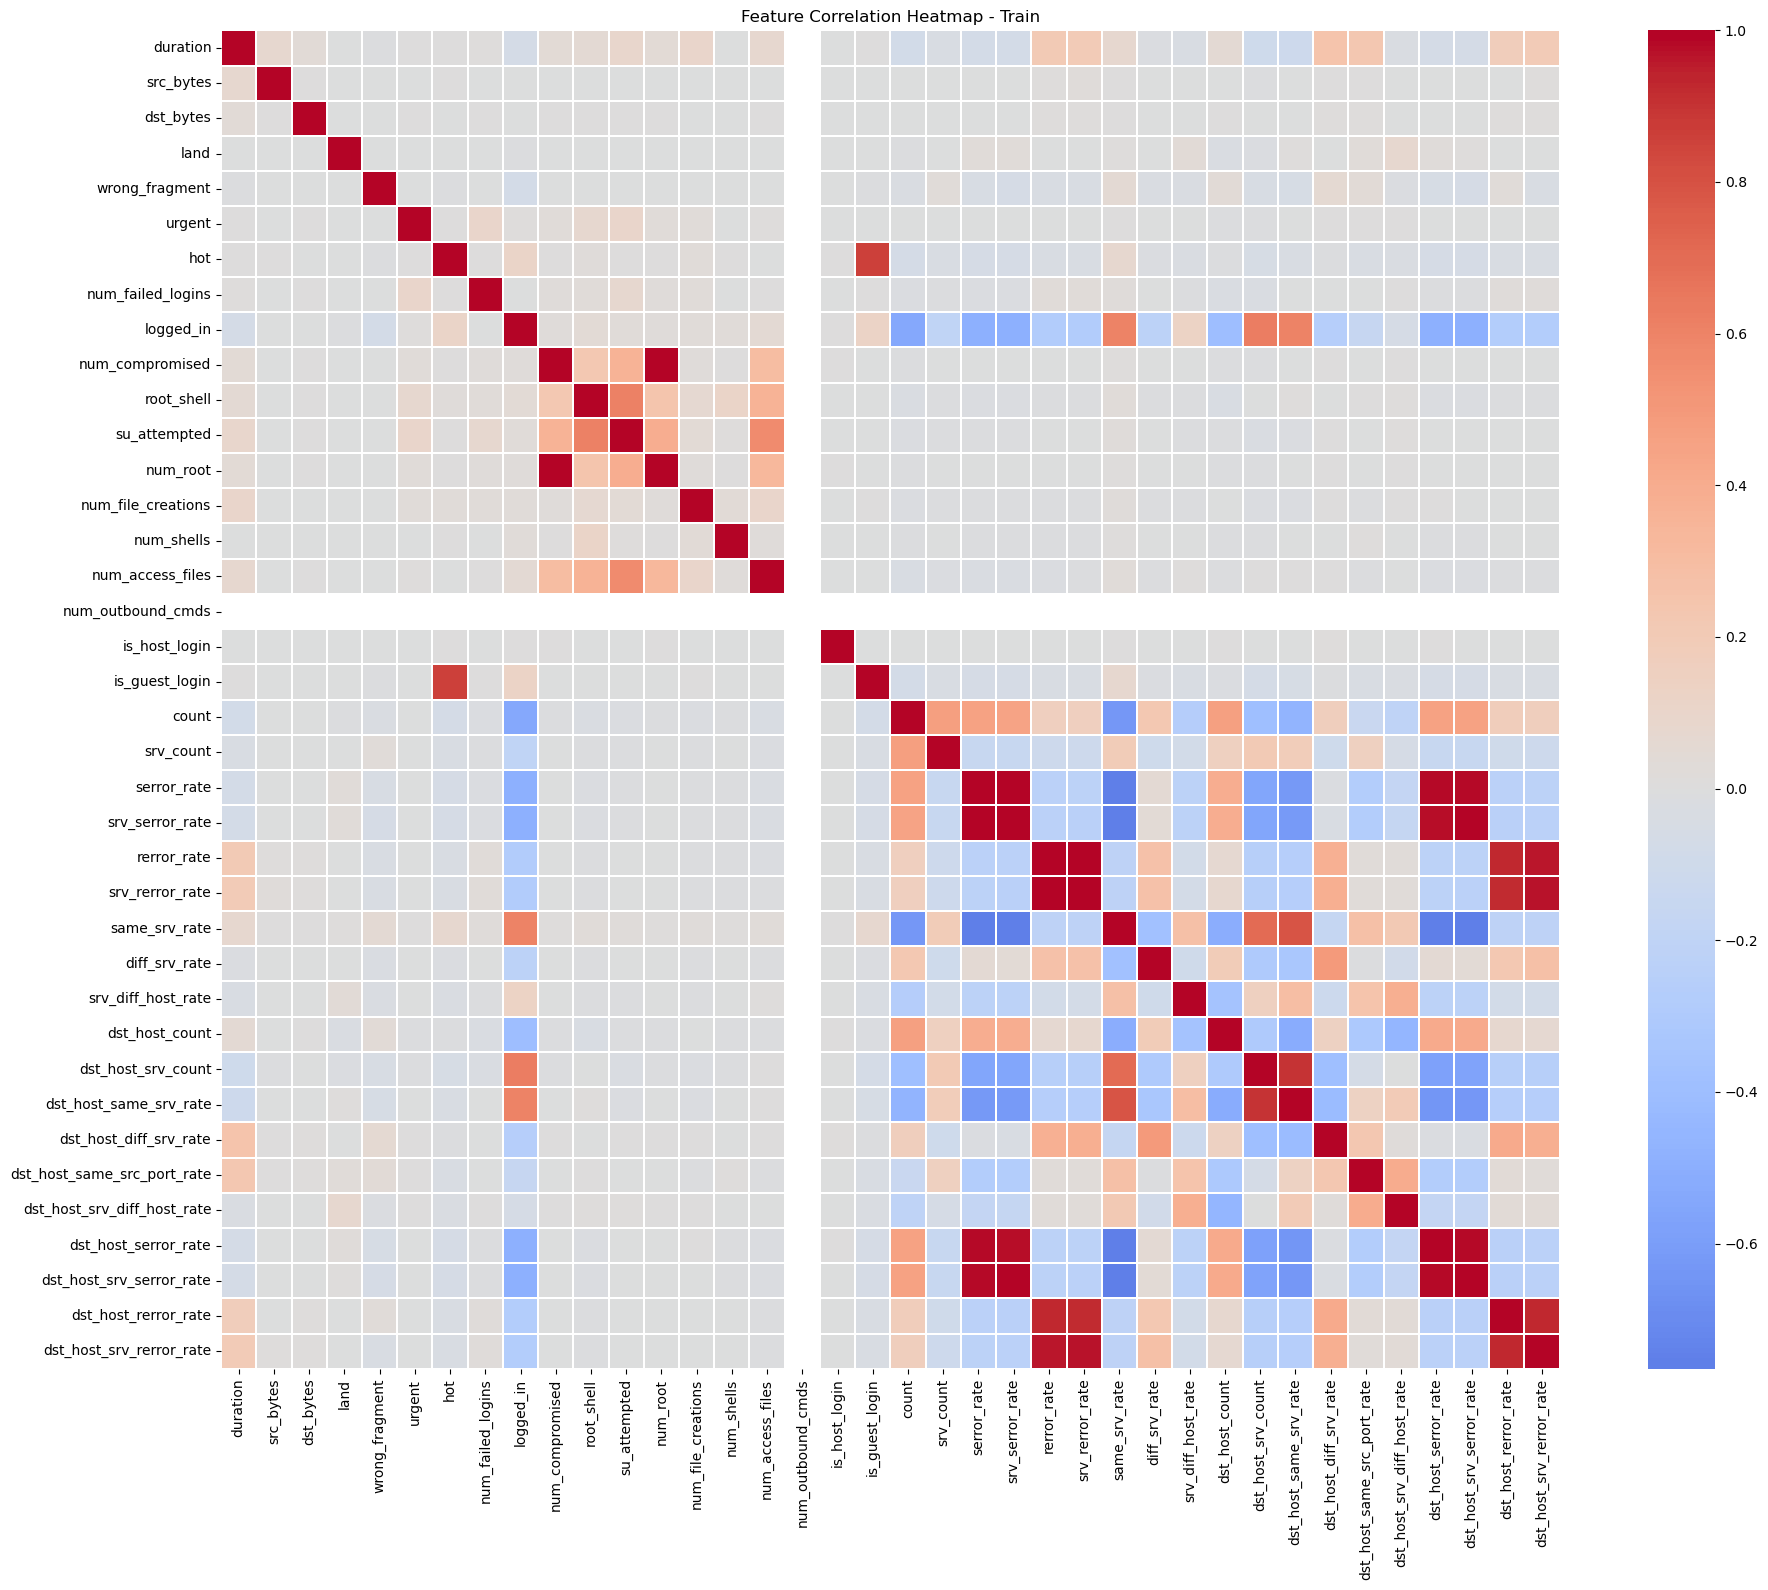

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [c for c in numerical_cols if c not in ['attack_binary']]

corr_matrix = df_train[corr_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.3)
plt.title('Feature Correlation Heatmap - Train')
plt.tight_layout()
plt.show()

In [195]:
def get_high_corr_pairs(corr_matrix, threshold=0.85):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append((cols[i], cols[j], round(val, 3)))
    return pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values(
        'correlation', ascending=False, key=abs)

high_corr = get_high_corr_pairs(corr_matrix, threshold=0.85)
print(high_corr)

               feature_1                 feature_2  correlation
1        num_compromised                  num_root        0.999
2            serror_rate           srv_serror_rate        0.993
7            rerror_rate           srv_rerror_rate        0.989
6        srv_serror_rate  dst_host_srv_serror_rate        0.986
13  dst_host_serror_rate  dst_host_srv_serror_rate        0.985
4            serror_rate  dst_host_srv_serror_rate        0.981
3            serror_rate      dst_host_serror_rate        0.979
5        srv_serror_rate      dst_host_serror_rate        0.978
11       srv_rerror_rate  dst_host_srv_rerror_rate        0.970
9            rerror_rate  dst_host_srv_rerror_rate        0.964
8            rerror_rate      dst_host_rerror_rate        0.927
14  dst_host_rerror_rate  dst_host_srv_rerror_rate        0.925
10       srv_rerror_rate      dst_host_rerror_rate        0.918
12    dst_host_srv_count    dst_host_same_srv_rate        0.897
0                    hot            is_g

In [197]:
for f1, f2, corr in high_corr.itertuples(index=False):
    print(f"{f1} vs {f2}: corr={corr}")
    print(f"{f1} correlation with attack_binary: {df_train[f1].corr(df_train['attack_binary']):.3f}")
    print(f"{f2} correlation with attack_binary: {df_train[f2].corr(df_train['attack_binary']):.3f}")
    print()

num_compromised vs num_root: corr=0.999
num_compromised correlation with attack_binary: -0.010
num_root correlation with attack_binary: -0.011

serror_rate vs srv_serror_rate: corr=0.993
serror_rate correlation with attack_binary: 0.651
srv_serror_rate correlation with attack_binary: 0.648

rerror_rate vs srv_rerror_rate: corr=0.989
rerror_rate correlation with attack_binary: 0.253
srv_rerror_rate correlation with attack_binary: 0.254

srv_serror_rate vs dst_host_srv_serror_rate: corr=0.986
srv_serror_rate correlation with attack_binary: 0.648
dst_host_srv_serror_rate correlation with attack_binary: 0.655

dst_host_serror_rate vs dst_host_srv_serror_rate: corr=0.985
dst_host_serror_rate correlation with attack_binary: 0.652
dst_host_srv_serror_rate correlation with attack_binary: 0.655

serror_rate vs dst_host_srv_serror_rate: corr=0.981
serror_rate correlation with attack_binary: 0.651
dst_host_srv_serror_rate correlation with attack_binary: 0.655

serror_rate vs dst_host_serror_rate:

In [199]:
# Check variance / constant columns
low_variance_report = []
for col in numerical_cols:
    if col == 'attack_binary':
        continue
    value_counts_norm = df_train[col].value_counts(normalize=True)
    top_value_pct = value_counts_norm.iloc[0]
    low_variance_report.append({
        'column': col,
        'nunique': df_train[col].nunique(),
        'top_value': value_counts_norm.index[0],
        'top_value_pct': round(top_value_pct * 100, 2)
    })

lv_df = pd.DataFrame(low_variance_report).sort_values('top_value_pct', ascending=False)
print(lv_df[lv_df['top_value_pct'] > 95])  # columns where one value dominates >95%

                column  nunique  top_value  top_value_pct
17       is_host_login        2        0.0         100.00
16   num_outbound_cmds        1        0.0         100.00
5               urgent        4        0.0          99.99
3                 land        2        0.0          99.98
14          num_shells        3        0.0          99.96
11        su_attempted        3        0.0          99.94
7    num_failed_logins        6        0.0          99.90
10          root_shell        2        0.0          99.87
13  num_file_creations       35        0.0          99.77
15    num_access_files       10        0.0          99.71
12            num_root       82        0.0          99.48
4       wrong_fragment        3        0.0          99.13
18      is_guest_login        2        0.0          99.06
9      num_compromised       88        0.0          98.98
6                  hot       28        0.0          97.88


In [201]:
# Drop the columns from the training data
df_train.drop(
    columns=[
        'serror_rate', 'srv_serror_rate', 'dst_host_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'dst_host_rerror_rate',
    'dst_host_same_srv_rate',
    'hot',
    'num_outbound_cmds', 'is_host_login',
    'num_compromised'
    ], 
    inplace=True
)

# Match the test data by dropping the exact same columns
df_test.drop(
    columns=[
        'serror_rate', 'srv_serror_rate', 'dst_host_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'dst_host_rerror_rate',
    'dst_host_same_srv_rate',
    'hot',
    'num_outbound_cmds', 'is_host_login',
    'num_compromised'
    ], 
    inplace=True
)


In [203]:
df_train.shape

(125973, 32)

In [211]:
print("Train unique services:", df_train['service'].nunique())
print("Test unique services:", df_test['service'].nunique())

print("\nTop 15 services - train")
print(df_train['service'].value_counts(normalize=True).head(15).round(4))

print("\nTop 15 services - test")
print(df_test['service'].value_counts(normalize=True).head(15).round(4))

Train unique services: 70
Test unique services: 66

Top 15 services - train
service
http        0.3202
private     0.1735
domain_u    0.0718
smtp        0.0581
ftp_data    0.0545
eco_i       0.0364
other       0.0346
ecr_i       0.0244
telnet      0.0187
finger      0.0140
ftp         0.0139
auth        0.0076
Z39_50      0.0068
uucp        0.0062
courier     0.0058
Name: proportion, dtype: float64

Top 15 services - test
service
http         0.3246
private      0.1855
domain_u     0.0636
smtp         0.0524
ftp_data     0.0474
telnet       0.0376
other        0.0359
eco_i        0.0275
ecr_i        0.0273
ftp          0.0184
pop_3        0.0162
finger       0.0124
imap4        0.0072
auth         0.0062
uucp_path    0.0055
Name: proportion, dtype: float64


In [213]:
train_services = set(df_train['service'].unique())
test_services = set(df_test['service'].unique())

only_in_test = test_services - train_services
only_in_train = train_services - test_services

print(f"Services only in TEST (not seen in train): {only_in_test}")
print(f"Count: {len(only_in_test)}")
print(f"\nServices only in TRAIN (not seen in test): {only_in_train}")
print(f"Count: {len(only_in_train)}")

Services only in TEST (not seen in train): set()
Count: 0

Services only in TRAIN (not seen in test): {'http_2784', 'harvest', 'http_8001', 'tftp_u'}
Count: 4


In [221]:
print(df_train['service'].value_counts()[['http_2784', 'harvest', 'http_8001', 'tftp_u']])

service
http_2784    1
harvest      2
http_8001    2
tftp_u       3
Name: count, dtype: int64


In [223]:
print(df_train.shape, df_test.shape)

(125973, 32) (22513, 32)


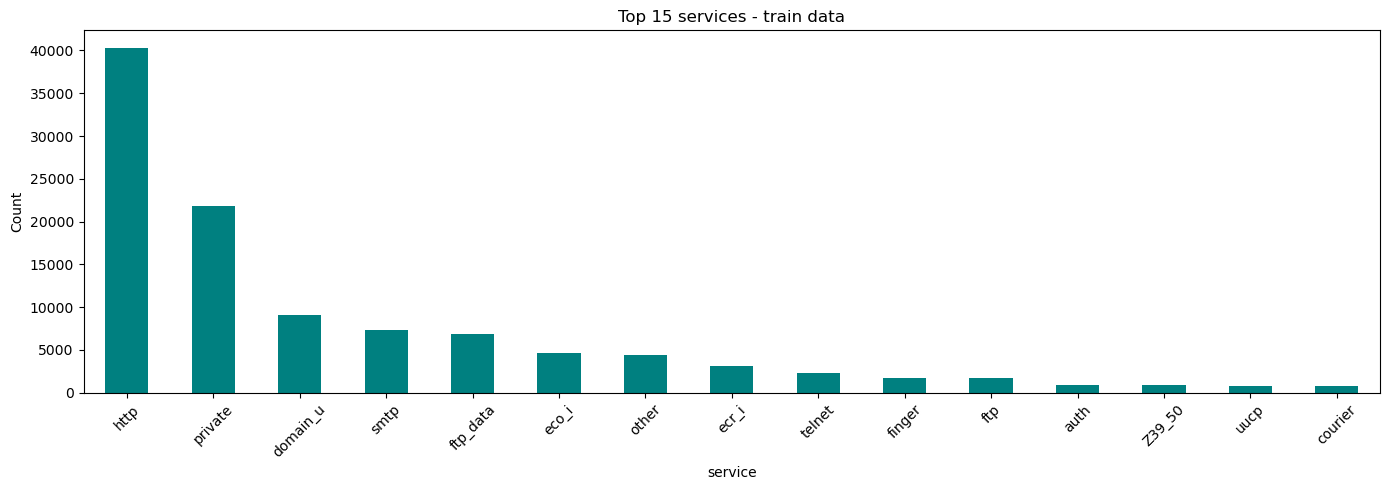

In [215]:
plt.figure(figsize=(14, 5))
df_train['service'].value_counts().head(15).plot(kind='bar', color='teal')
plt.title('Top 15 services - train data')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

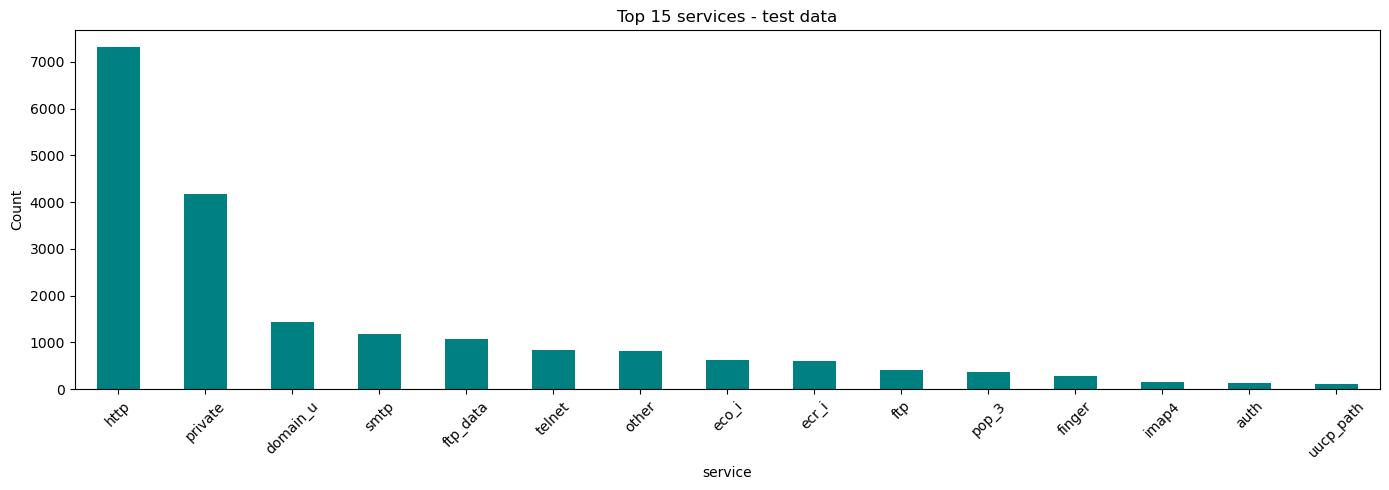

In [217]:
plt.figure(figsize=(14, 5))
df_test['service'].value_counts().head(15).plot(kind='bar', color='teal')
plt.title('Top 15 services - test data')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [219]:
unseen_mask = df_test['service'].isin(only_in_test)
print(f"Rows in test with an unseen service category: {unseen_mask.sum()} ({unseen_mask.mean()*100:.2f}%)")

Rows in test with an unseen service category: 0 (0.00%)


In [229]:
encoder = OneHotEncoder(handle_unknown='ignore')  
encoder.fit(df_train[['service']])

OneHotEncoder(handle_unknown='ignore')

In [243]:
# Only if you still have the multiclass label around
if 'labels' in df_train.columns:
    print(df_train[df_train['attack_binary']==1]['labels'].value_counts().head(10))

labels
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
pod              201
Name: count, dtype: int64


In [245]:
print(df_train[df_train['attack_binary']==1]['labels'].value_counts().tail(15))

labels
teardrop           892
warezclient        890
pod                201
guess_passwd        53
buffer_overflow     30
warezmaster         20
land                18
imap                11
rootkit             10
loadmodule           9
ftp_write            8
multihop             7
phf                  4
perl                 3
spy                  2
Name: count, dtype: int64


In [249]:
cols_to_check = ['src_bytes', 'dst_bytes', 'duration', 'count']

for col in cols_to_check:
    print(f"{col}: skewness = {skew(df_train[col]):.2f}")

src_bytes: skewness = 190.67
dst_bytes: skewness = 290.05
duration: skewness = 11.88
count: skewness = 1.51


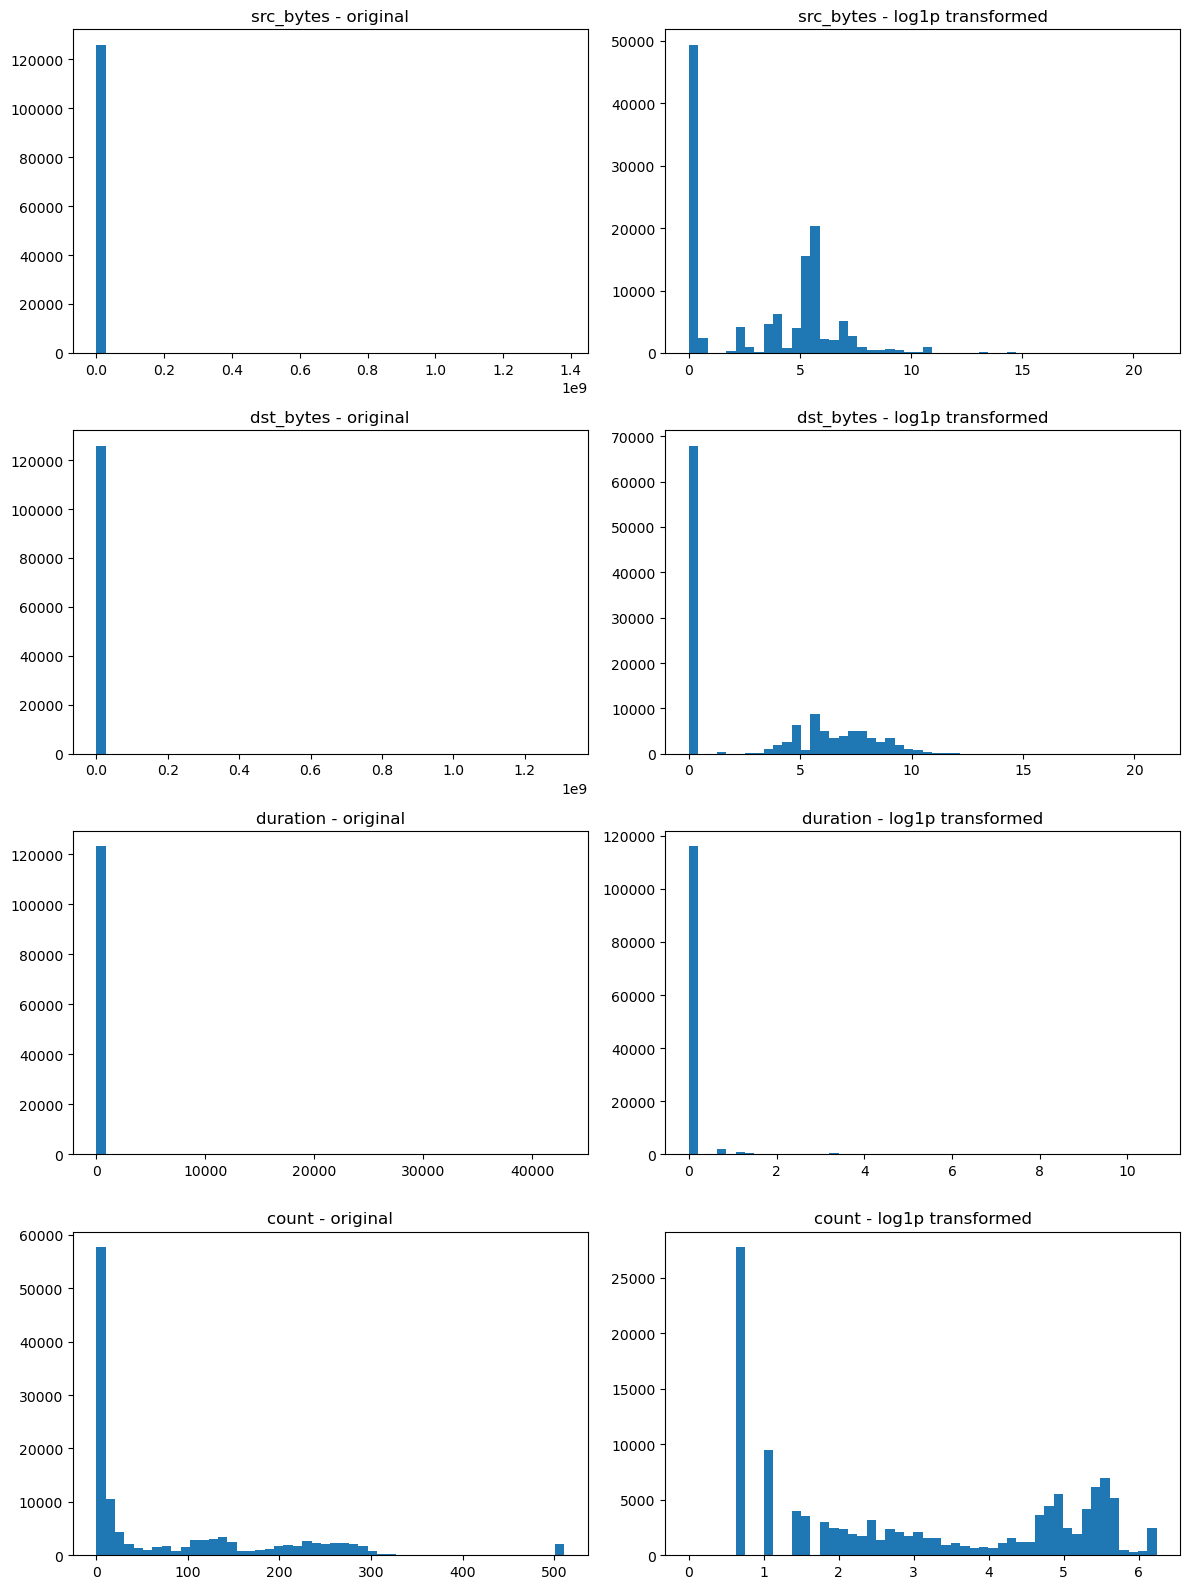

In [251]:
fig, axes = plt.subplots(len(cols_to_check), 2, figsize=(12, 4*len(cols_to_check)))

for i, col in enumerate(cols_to_check):
    axes[i,0].hist(df_train[col], bins=50)
    axes[i,0].set_title(f'{col} - original')
    
    axes[i,1].hist(np.log1p(df_train[col]), bins=50)
    axes[i,1].set_title(f'{col} - log1p transformed')

plt.tight_layout()
plt.show()

In [253]:
print((df_train['duration'] == 0).mean())

0.9204750224254403


In [255]:
print(df_train.groupby('attack_binary')['duration'].apply(lambda x: (x==0).mean()))

attack_binary
0    0.881844
1    0.964847
Name: duration, dtype: float64


In [257]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = ['protocol_type', 'service', 'flag']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(df_train[categorical_cols])  # fit on train ONLY

train_encoded = pd.DataFrame(
    encoder.transform(df_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_train.index
)
test_encoded = pd.DataFrame(
    encoder.transform(df_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_test.index
)

df_train = pd.concat([df_train.drop(columns=categorical_cols), train_encoded], axis=1)
df_test = pd.concat([df_test.drop(columns=categorical_cols), test_encoded], axis=1)

print(df_train.shape, df_test.shape)

(125973, 113) (22513, 113)


In [259]:
df_train.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'num_failed_logins', 'logged_in', 'root_shell',
       'su_attempted',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='object', length=113)

In [261]:
from sklearn.preprocessing import StandardScaler

numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['attack_binary']]  # never scale the target

scaler = StandardScaler()
scaler.fit(df_train[numerical_cols])  # fit on train ONLY

df_train[numerical_cols] = scaler.transform(df_train[numerical_cols])
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

In [263]:
# Confirm no leftover object/category dtypes
print(df_train.dtypes.value_counts())
print(df_test.dtypes.value_counts())

# Confirm shapes match on columns (minus target)
assert set(df_train.columns) == set(df_test.columns)

float64    111
object       1
int64        1
Name: count, dtype: int64
float64    111
object       1
int64        1
Name: count, dtype: int64


In [265]:
object_cols = df_train.select_dtypes(include=['object']).columns.tolist()
print(object_cols)

['labels']


In [267]:
df_train.drop(columns=['labels'], inplace=True)
df_test.drop(columns=['labels'], inplace=True)

In [274]:
df_train.to_csv('../data/clean_kdd_train.csv',index=False)
df_test.to_csv('../data/clean_kdd_test.csv',index=False)